In [140]:
import torch
import torch.utils.data
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import numpy as np
import random

In [141]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [142]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [143]:
from pathlib import Path

data_dir=Path() / "data" / "mnist"

data_dir.absolute()

WindowsPath('C:/LANG_CHAIN_2026/2026-05-19_KDT_lang_chain/workspace/python/16_pytorch/data/mnist')

In [144]:
if not data_dir.exists():
    data_dir.mkdir(parents=True, exist_ok=True)

test_dir = data_dir / "test"
train_dir = data_dir / "train"

In [145]:
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.RandomAffine(degrees=15, translate=(0.25, 0.25), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    # transforms.Normalize()
])

In [146]:
# Modified National Institute of standards and Technology
mnist = datasets.MNIST(
    root=train_dir,
    train=True,
    transform=train_transform,
    target_transform=None,
    download=True
)

In [147]:
type(mnist)

torchvision.datasets.mnist.MNIST

In [148]:
type(mnist[0]), mnist.targets.shape, mnist.data.shape, mnist.classes, mnist.class_to_idx, len(mnist), isinstance(mnist, torch.utils.data.Dataset),

(tuple,
 torch.Size([60000]),
 torch.Size([60000, 28, 28]),
 ['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'],
 {'0 - zero': 0,
  '1 - one': 1,
  '2 - two': 2,
  '3 - three': 3,
  '4 - four': 4,
  '5 - five': 5,
  '6 - six': 6,
  '7 - seven': 7,
  '8 - eight': 8,
  '9 - nine': 9},
 60000,
 True)

In [149]:
mnist[0][0].max(),mnist[0][0].min()

(tensor(1.), tensor(0.))

In [150]:
mnist[0][0].squeeze(0).shape

torch.Size([28, 28])

<class 'numpy.ndarray'>
<class 'int'>


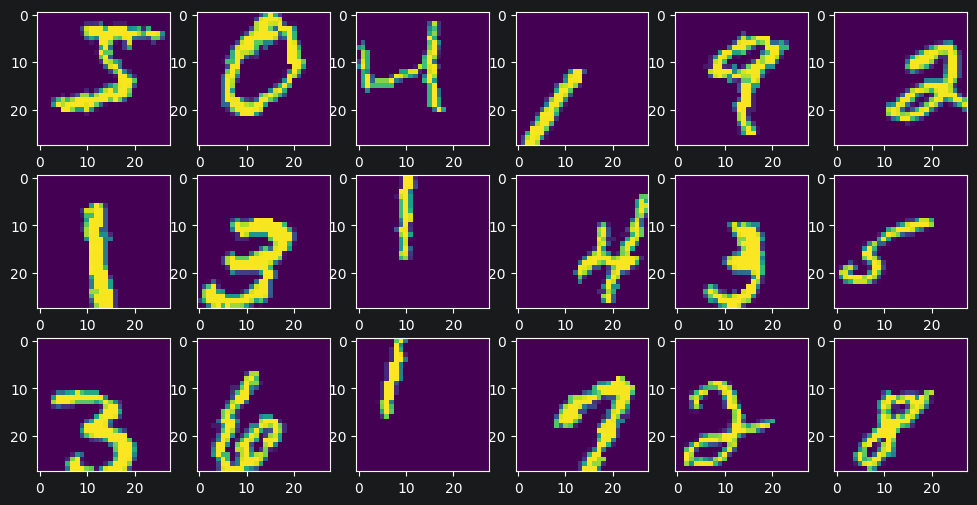

In [151]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 6, figsize=(12, 6))

print(type(axes))
print(type(len(axes.flat)))
for idx, ax in enumerate(axes.flat):
    img, label = mnist[idx]
    ax.imshow(img.squeeze(0), vmin=0, vmax=1)
plt.show()

<class 'numpy.ndarray'>
<class 'int'>


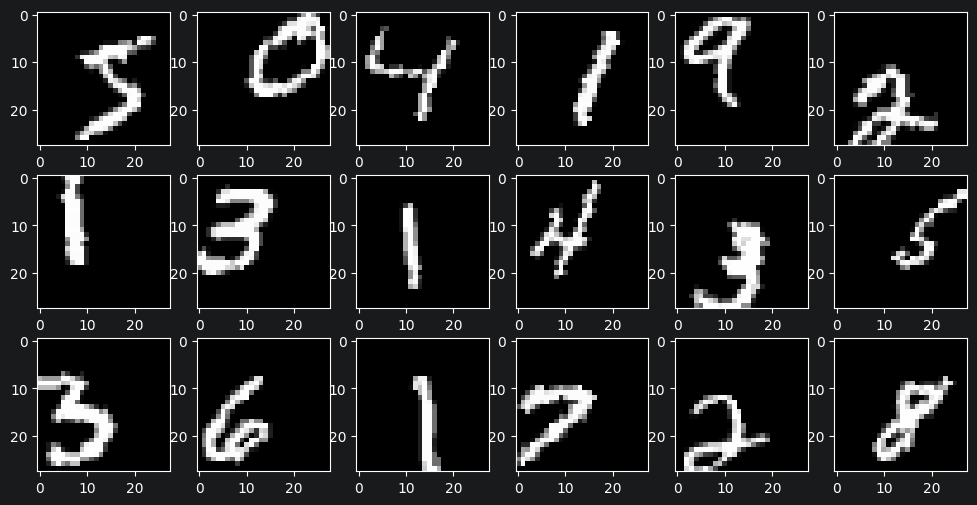

In [152]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))

print(type(axes))
print(type(len(axes.flat)))
for idx, ax in enumerate(axes.flat):
    img, label = mnist[idx]
    ax.imshow(img.squeeze(0), cmap="gray", vmin=0, vmax=1)
plt.show()

In [153]:
train_loader = DataLoader(
    dataset=mnist,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=False
)

In [154]:
type(next(iter(train_loader)))

list

In [155]:
len(next(iter(train_loader)))

2

In [156]:
next(iter(train_loader))[0].shape

torch.Size([32, 1, 28, 28])

<class 'numpy.ndarray'>
<class 'int'>


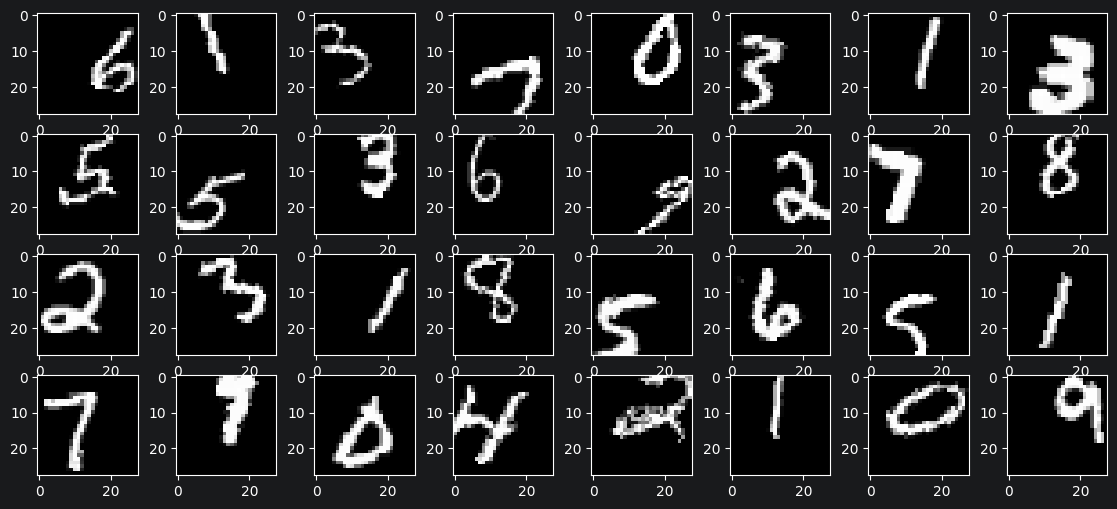

In [157]:
fig, axes = plt.subplots(4, 8, figsize=(14, 6))

print(type(axes))
print(type(len(axes.flat)))

images, labels = next(iter(train_loader))

for idx, ax in enumerate(axes.flat):
    img, label = images[idx], labels[idx]
    ax.imshow(img.squeeze(0), cmap="gray", vmin=0, vmax=1)
plt.show()

<class 'numpy.ndarray'>
<class 'int'>


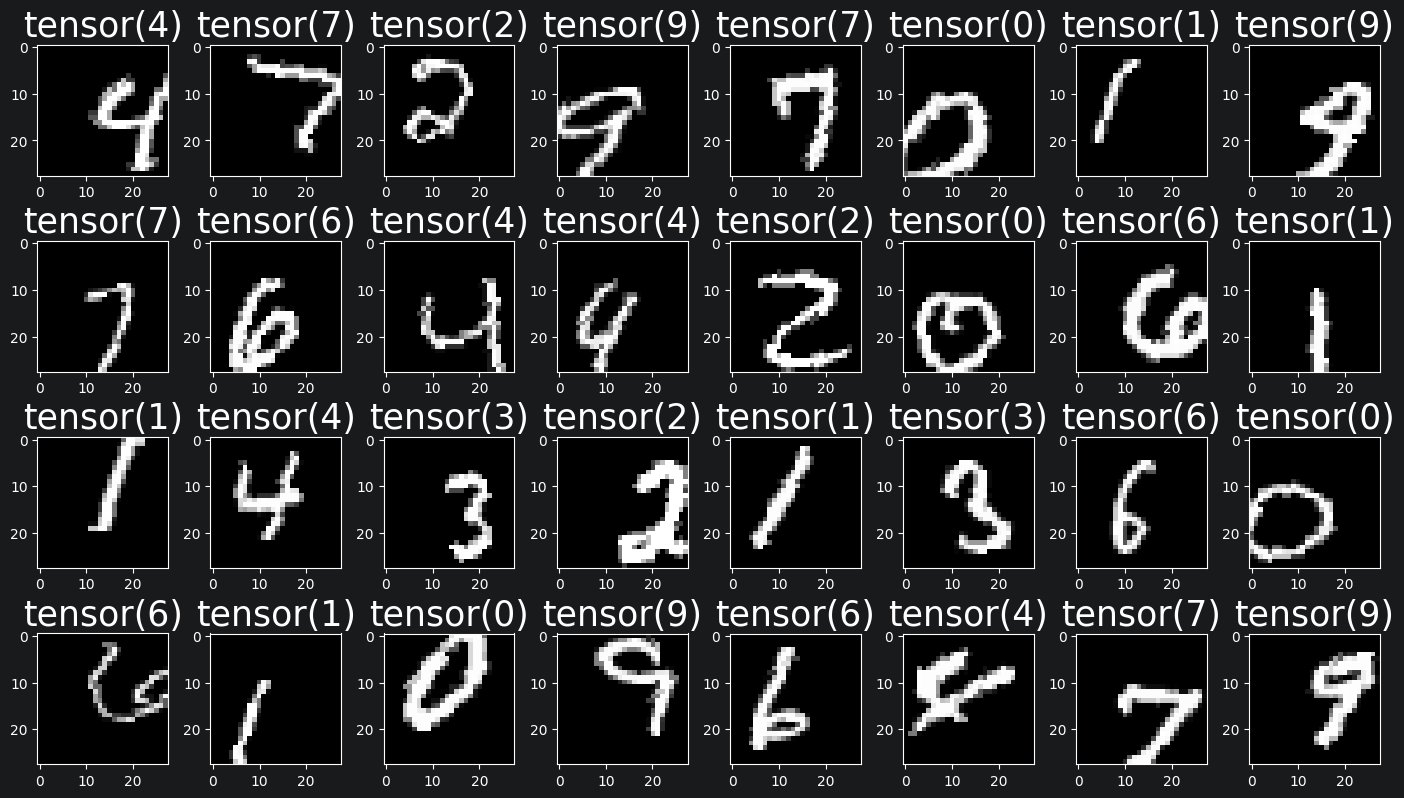

In [158]:
fig, axes = plt.subplots(4, 8, figsize=(14, 8))

print(type(axes))
print(type(len(axes.flat)))

images, labels = next(iter(train_loader))

for idx, ax in enumerate(axes.flat):
    img, label = images[idx], labels[idx]
    ax.imshow(img.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(label, fontsize=25)

plt.tight_layout()
plt.show()

In [159]:
from torch import nn

class NumberCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),

            nn.Conv2d(8, 16, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2), # 14

            nn.Conv2d(16, 16, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 8, kernel_size=3, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2), # 7
        )

        self.fc = nn.Sequential(
            # 채널 [8, 2, 2]
            nn.AdaptiveAvgPool2d((2, 2)),

            nn.Flatten(),

            # logits (softmax 전)
            nn.Linear(32, 10)
        )

    def forward(self, x: torch.Tensor):
        x = self.features(x)
        return self.fc(x)

In [160]:
model = NumberCNN().to(device)

In [161]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [162]:
torch.argmax(model(next(iter(train_loader))[0].to(device)), dim=1)

tensor([8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8], device='cuda:0')

In [170]:
def pred_one_batch(model):
    model.eval()

    with torch.inference_mode():

        fig, axes = plt.subplots(4, 8, figsize=(14, 8))

        batch =next(iter(train_loader))

        images, labels = batch

        pred = torch.argmax(model(images.to(device)), dim=1)

        for idx, ax in enumerate(axes.flat):
            img = images[idx]
            target = labels[idx]

            ax.imshow(img.squeeze(0), vmin=0, vmax=1, cmap="gray")
            ax.set_title(f"target: {target.item()}\npred: {pred[idx].item()}", fontsize=20)

        plt.tight_layout()
        plt.show()

    model.train()

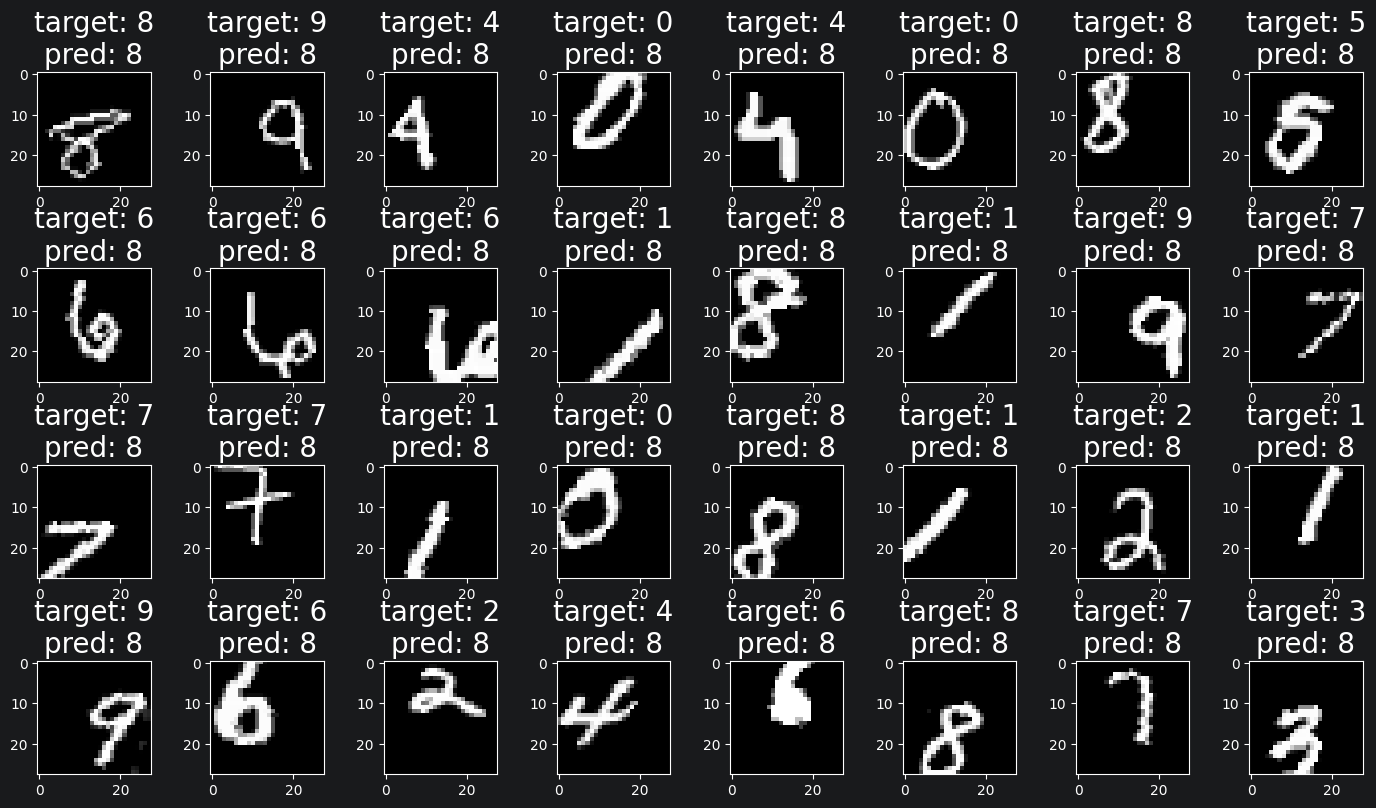

In [164]:
pred_one_batch(model)

In [180]:
def trainNumberCNN(epochs, loader=train_loader):
    print("loader len:", len(train_loader))
    print("loader batch_size:", train_loader.batch_size)

    for epoch in range(1, epochs+1):

        loss_sum = 0
        accuracy_sum=0

        for images, labels in train_loader:
            pred = model(images.to(device))

            loss = criterion(pred, labels.to(device))

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            loss_sum += loss

            accuracy = (torch.argmax(pred, dim=1) == labels.to(device)).sum()

            accuracy_sum += accuracy

        print("epoch:", epoch)
        print("avg loss:", loss_sum / len(train_loader.dataset))
        print("avg accuracy:",accuracy_sum / len(train_loader.dataset))



In [166]:
trainNumberCNN(1)

loader len: 1875
loader batch_size: 32
epoch: 1
tensor(1.1266, device='cuda:0', grad_fn=<DivBackward0>)


In [167]:
trainNumberCNN(1)

loader len: 1875
loader batch_size: 32
epoch: 1
tensor(0.5585, device='cuda:0', grad_fn=<DivBackward0>)


In [181]:
trainNumberCNN(1)

loader len: 1875
loader batch_size: 32
epoch: 1
avg loss: tensor(0.0108, device='cuda:0', grad_fn=<DivBackward0>)
avg accuracy: tensor(0.8933, device='cuda:0')


In [173]:
print(len(train_loader))

1875


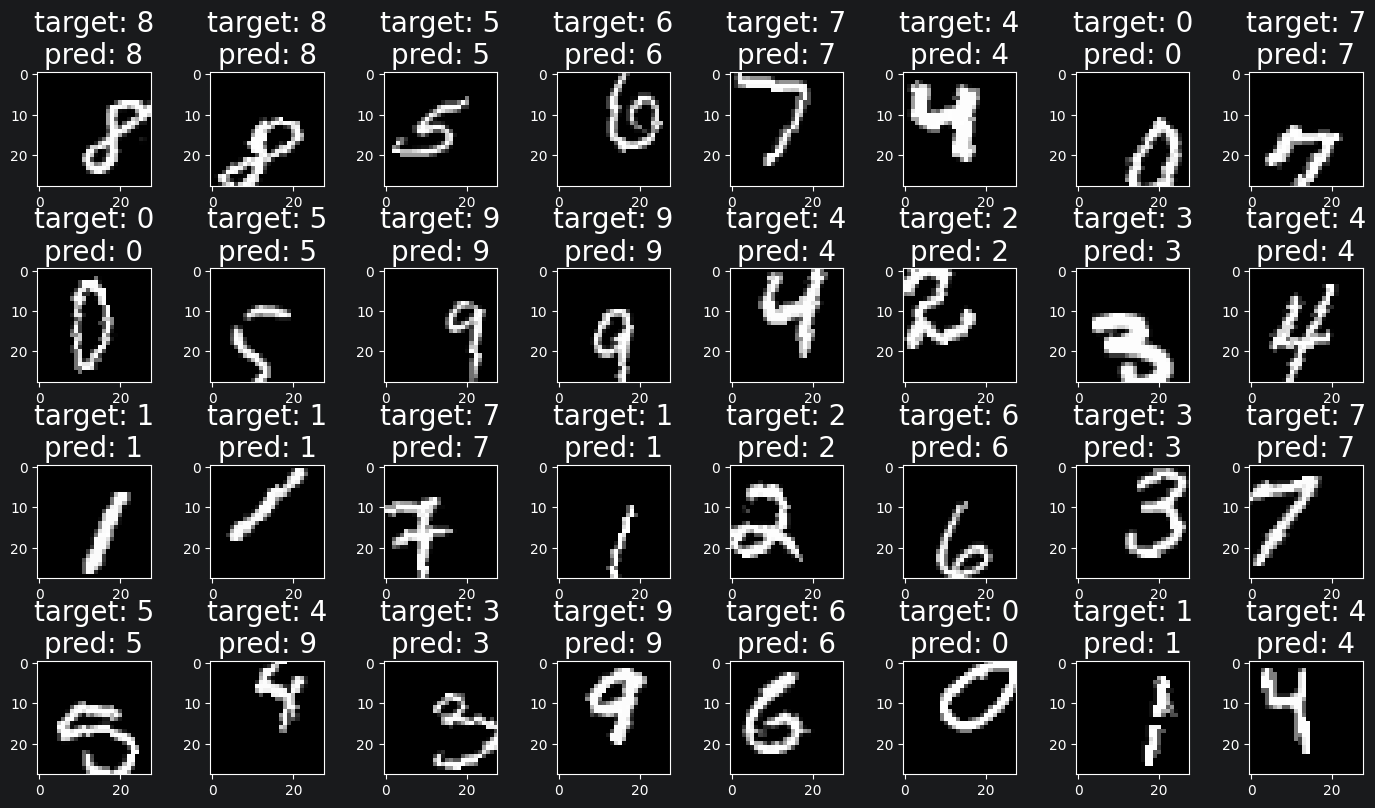

In [182]:
pred_one_batch(model)